/tmp/ipykernel_26369/2139813537.py:426: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


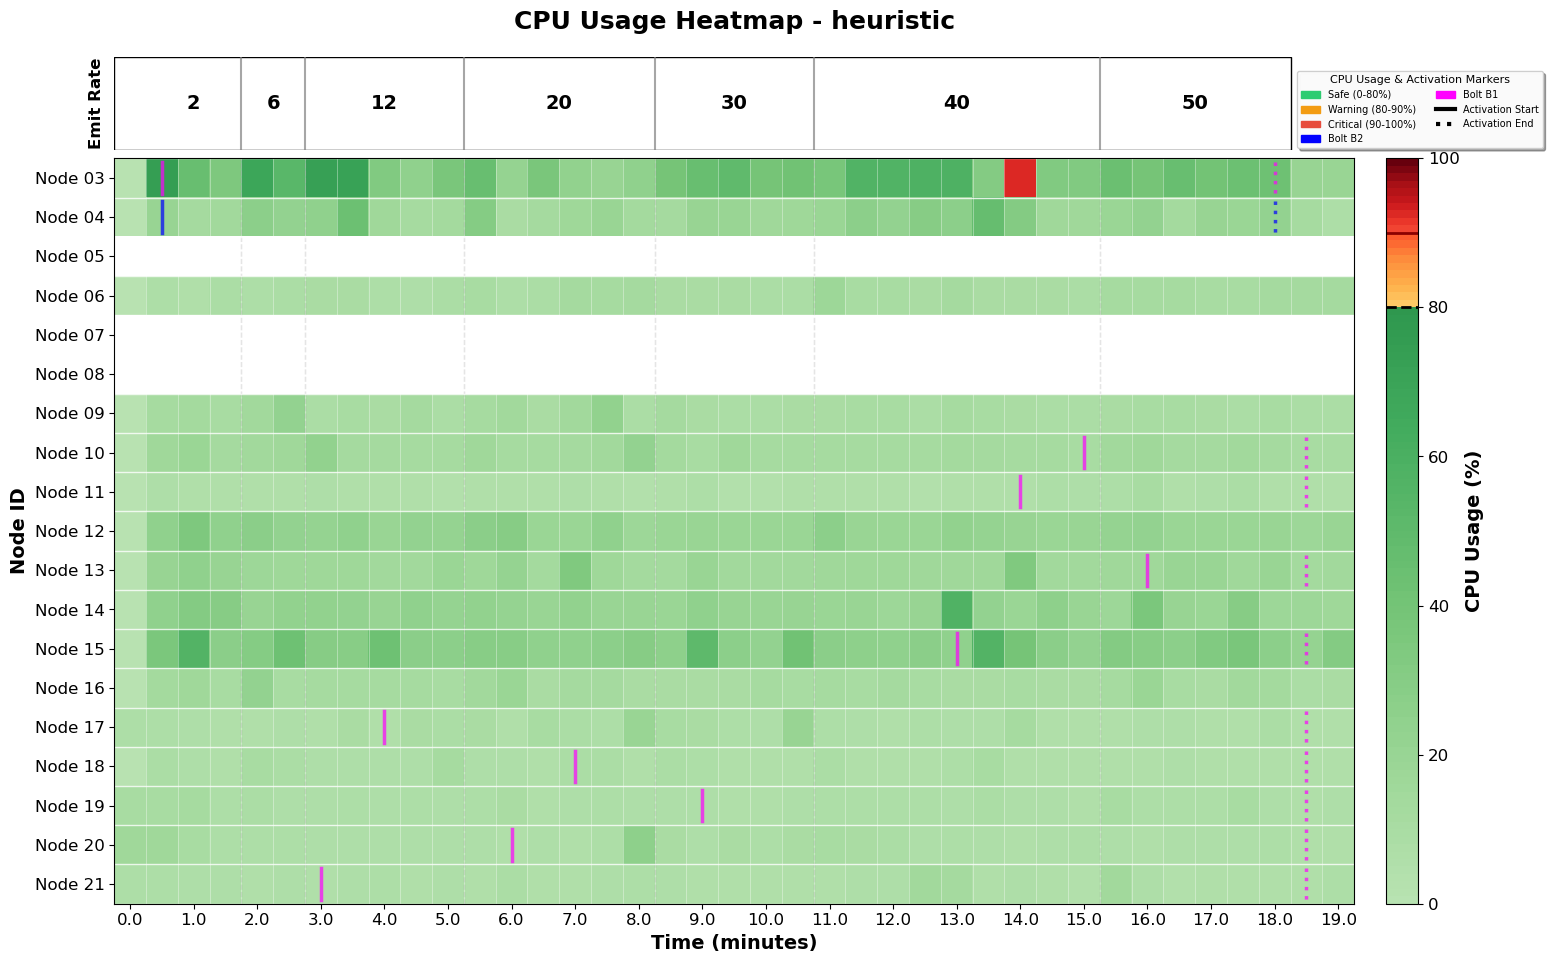


Heatmap Summary:
Number of approaches: 1
Approaches: ['heuristic']
Time range: 0.0 to 19.0 minutes
Number of nodes: 19

Activation Markers Summary (specified in cycles):
  heuristic:
    as00750-03: cycle 1-36 (Bolt B1)
    as00750-04: cycle 1-36 (Bolt B2)
    as00750-21: cycle 6-37 (Bolt B1)
    as00750-17: cycle 8-37 (Bolt B1)
    as00750-20: cycle 12-37 (Bolt B1)
    as00750-18: cycle 14-37 (Bolt B1)
    as00750-19: cycle 18-37 (Bolt B1)
    as00750-15: cycle 26-37 (Bolt B1)
    as00750-11: cycle 28-37 (Bolt B1)
    as00750-10: cycle 30-37 (Bolt B1)
    as00750-13: cycle 32-37 (Bolt B1)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Set style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# === User-defined parameters ===
cycle_duration_sec = 30   # Duration of each cycle in seconds
x_axis_unit = 'minutes'   # Choose 'minutes' or 'seconds'
cycle_start = 0           # First cycle to include
cycle_end = 55          # Last cycle to include

# Define which VMs to plot
vms_to_plot = ["as00750-03", "as00750-04", "as00750-05", "as00750-06",
               "as00750-07", "as00750-08", "as00750-09", "as00750-10", "as00750-11", 
               "as00750-12", "as00750-13", "as00750-14", "as00750-15", "as00750-16", 
               "as00750-17", "as00750-18", "as00750-19", "as00750-20", "as00750-21"]
# === NEW: Bolt colors and activation markers (now specified in CYCLES) ===
BOLT_COLORS = {
    'b1': 'magenta',
    'b2': 'blue'
}

activation_markers = {

     "heuristic": {
         "as00750-03": [[1, 36, BOLT_COLORS['b1'], '-', ':']],
        "as00750-04": [[1, 36, BOLT_COLORS['b2'], '-', ':']],
        "as00750-21":[[6, 37, BOLT_COLORS['b1'], '-', ':']],
        "as00750-17": [[8, 37, BOLT_COLORS['b1'], '-', ':']],
        "as00750-20": [[12, 37, BOLT_COLORS['b1'], '-', ':']],
        "as00750-18": [[14, 37, BOLT_COLORS['b1'], '-', ':']],
        "as00750-19":[[18, 37, BOLT_COLORS['b1'], '-', ':']],
        "as00750-15": [[26, 37, BOLT_COLORS['b1'], '-', ':']],
 	"as00750-11": [[28, 37, BOLT_COLORS['b1'], '-', ':']],
 	"as00750-10": [[30, 37, BOLT_COLORS['b1'], '-', ':']],
 	"as00750-13": [[32, 37, BOLT_COLORS['b1'], '-', ':']],
    },

  
}
# === Function to extract approach name ===
def extract_approach_name(filename, prefix='aggregated_CPU_usage_', suffix='.csv'):
    if filename.startswith(prefix) and filename.endswith(suffix):
        start = len(prefix)
        end = len(filename) - len(suffix)
        return filename[start:end]
    else:
        print(f"Warning: Filename '{filename}' does not match the expected pattern.")
        return None

# === Locate CSV files ===
file_list = glob.glob('aggregated_CPU_usage_*.csv')
if not file_list:
    print("No CSV files found matching 'aggregated_CPU_usage_*.csv'")
    exit(1)

# === Data structures for heatmaps ===
approach_data_dict = {}  # {approach_name: {vm_name: {time: cpu_usage}}}
emit_rate_data = {}  # Store emit rate data per approach

# ---------------------------------------------------------------------
# 1) Read each CSV and organize data for heatmaps
# ---------------------------------------------------------------------
for fname in file_list:
    cpu_data = pd.read_csv(fname, header=0)
    
    # Convert CPU usage to percent
    cpu_data['CPU usage'] = cpu_data['CPU usage'] * 100.0
    
    # Filter cycles
    cpu_data = cpu_data[
        (cpu_data['cycleCount'] >= cycle_start) &
        (cpu_data['cycleCount'] <= cycle_end)
    ].copy()
    
    if cpu_data.empty:
        continue
    
    # Convert cycle -> Time
    cpu_data['Time'] = cpu_data['cycleCount'] * cycle_duration_sec
    if x_axis_unit == 'minutes':
        cpu_data['Time'] /= 60.0
    
    # Extract approach name
    approach_name = extract_approach_name(os.path.basename(fname))
    if approach_name not in approach_data_dict:
        approach_data_dict[approach_name] = {}
    
    # Store emit rate data
    if 'EmitRate' in cpu_data.columns:
        emit_rate_by_time = cpu_data.groupby('Time')['EmitRate'].first().to_dict()
        emit_rate_data[approach_name] = emit_rate_by_time
    
    # Group by VM and Time
    for vm in vms_to_plot:
        vm_data = cpu_data[cpu_data['VM Name'] == vm]
        if not vm_data.empty:
            # Average CPU usage at each time point
            time_cpu = vm_data.groupby('Time')['CPU usage'].mean().to_dict()
            approach_data_dict[approach_name][vm] = time_cpu

# ---------------------------------------------------------------------
# 2) Create heatmap matrices with interpolation
# ---------------------------------------------------------------------
# Get all unique time points across all approaches
all_times = set()
for approach_data in approach_data_dict.values():
    for vm_data in approach_data.values():
        all_times.update(vm_data.keys())
all_times = sorted(list(all_times))

# Create matrices with interpolation for missing values
approach_matrices = {}
for approach_name, approach_data in approach_data_dict.items():
    # Initialize matrix with NaN
    matrix = np.full((len(vms_to_plot), len(all_times)), np.nan)
    
    # Fill matrix
    for i, vm in enumerate(vms_to_plot):
        if vm in approach_data:
            vm_times = sorted(approach_data[vm].keys())
            vm_values = [approach_data[vm][t] for t in vm_times]
            
            # Interpolate to fill all time points
            if len(vm_times) > 1:
                interp_values = np.interp(all_times, vm_times, vm_values)
                matrix[i, :] = interp_values
            elif len(vm_times) == 1:
                # If only one data point, use it for the corresponding time
                time_idx = all_times.index(vm_times[0])
                matrix[i, time_idx] = vm_values[0]
    
    approach_matrices[approach_name] = matrix

# === NEW: Helper function to find time index ===
def find_time_index(target_time, all_times):
    """Find the closest index in all_times for the target_time"""
    if not all_times:
        return 0
    
    # Find closest time point
    closest_idx = 0
    min_diff = abs(all_times[0] - target_time)
    
    for i, time_point in enumerate(all_times):
        diff = abs(time_point - target_time)
        if diff < min_diff:
            min_diff = diff
            closest_idx = i
    
    return closest_idx

# ---------------------------------------------------------------------
# 3) Create CLEANER heatmap with emit rate visualization and activation markers
# ---------------------------------------------------------------------
# Order of approaches
approach_order = ['heuristic', 'staticWeights', 'globalAdaptationOnly', 
                  'noLocal_noGlobal', 'storm_replication']
approaches_to_plot = [app for app in approach_order if app in approach_matrices]
approaches_to_plot += [app for app in approach_matrices if app not in approach_order]

# Create individual plots for each approach with enhanced clarity
for approach_name in approaches_to_plot:
    # Create figure with subplots - back to original layout but with better spacing
    fig = plt.figure(figsize=(16, 11))
    gs = GridSpec(2, 1, height_ratios=[1, 8], hspace=0.02, figure=fig)
    
    # Emit rate subplot
    ax_emit = fig.add_subplot(gs[0])
    # CPU heatmap subplot
    ax = fig.add_subplot(gs[1])
    
    matrix = approach_matrices[approach_name]
    
    # ---------------------------------------------------------------------
    # Check if there are any non-zero emit rates
    # ---------------------------------------------------------------------
    has_non_zero_emit_rate = False
    last_non_zero_index = -1
    if approach_name in emit_rate_data:
        emit_rates = []
        for t in all_times:
            rate = emit_rate_data[approach_name].get(t, 0)
            emit_rates.append(rate)
        has_non_zero_emit_rate = any(rate > 0 for rate in emit_rates)
        
        # Find the last index where emit rate is non-zero
        if has_non_zero_emit_rate:
            for i in range(len(emit_rates) - 1, -1, -1):
                if emit_rates[i] > 0:
                    last_non_zero_index = i
                    break
    
    # ---------------------------------------------------------------------
    # Plot emit rate bar chart at the top (only if non-zero rates exist)
    # ---------------------------------------------------------------------
    if has_non_zero_emit_rate:
        # Create simple display for emit rate
        ax_emit.set_facecolor('white')
        
        # Add text labels for emit rate values
        prev_rate = None
        start_idx = 0
        
        for i, rate in enumerate(emit_rates):
            if i > last_non_zero_index:
                break
                
            if rate != prev_rate:
                if prev_rate is not None and prev_rate > 0:  # Only show non-zero rates
                    # Add label for previous segment
                    mid_idx = (start_idx + i - 1) / 2
                    ax_emit.text(mid_idx, 0.5, f'{int(prev_rate)}', 
                               ha='center', va='center', fontsize=14, 
                               fontweight='bold', color='black')
                
                # Only add vertical line if we're transitioning between non-zero rates
                if prev_rate is not None and prev_rate > 0 and rate > 0:
                    ax_emit.axvline(x=i-0.5, color='gray', linewidth=1.5, alpha=0.7)
                    ax.axvline(x=i-0.5, color='gray', linewidth=1, alpha=0.3, linestyle='--')
                
                start_idx = i
            prev_rate = rate
        
        # Add label for last segment
        if prev_rate is not None and prev_rate > 0:  # Only show non-zero rates
            mid_idx = (start_idx + last_non_zero_index) / 2
            ax_emit.text(mid_idx, 0.5, f'{int(prev_rate)}', 
                       ha='center', va='center', fontsize=14, 
                       fontweight='bold', color='black')
        
        # Format emit rate axis
        ax_emit.set_xlim(-0.5, len(all_times)-0.5)
        ax_emit.set_ylim(0, 1)
        ax_emit.set_ylabel('Emit Rate', fontsize=12, fontweight='bold')
        ax_emit.set_xticks([])
        ax_emit.set_yticks([])
        
        # Remove default spines
        for spine in ax_emit.spines.values():
            spine.set_visible(False)
        
        # Draw custom box that ends where emit rates become 0
        import matplotlib.patches as patches
        box_width = (last_non_zero_index + 1) / len(all_times)
        rect = patches.Rectangle((0, 0), box_width, 1, 
                                linewidth=1, edgecolor='black', 
                                facecolor='none', transform=ax_emit.transAxes)
        ax_emit.add_patch(rect)
        
        # Add title above emit rate
        ax_emit.set_title(f'CPU Usage Heatmap - {approach_name}', 
                         fontsize=18, fontweight='bold', pad=20)
    else:
        ax_emit.set_visible(False)
        ax.set_title(f'CPU Usage Heatmap - {approach_name}', 
                    fontsize=18, fontweight='bold', pad=20)
    
    # ---------------------------------------------------------------------
    # Plot CPU usage heatmap
    # ---------------------------------------------------------------------
    # Create custom colormap with clear thresholds
    n_green = 80  # 0-80% will be shades of green
    n_yellow = 10  # 80-90% will be shades of yellow/orange
    n_red = 10     # 90-100% will be shades of red
    
    # Create color arrays
    greens = plt.cm.Greens(np.linspace(0.3, 0.7, n_green))
    yellows = plt.cm.YlOrRd(np.linspace(0.3, 0.6, n_yellow))
    reds = plt.cm.Reds(np.linspace(0.6, 1.0, n_red))
    
    # Combine all colors
    all_colors = np.vstack([greens, yellows, reds])
    cmap = ListedColormap(all_colors)
    
    # Create heatmap with square grid cells
    im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=0, vmax=100, 
                   interpolation='nearest')
    
    # Add grid lines between nodes for clarity
    for i in range(len(vms_to_plot) + 1):
        ax.axhline(y=i-0.5, color='white', linewidth=1, alpha=0.8)
    
    # Vertical lines for time grid
    for j in range(len(all_times) + 1):
        ax.axvline(x=j-0.5, color='white', linewidth=0.5, alpha=0.5)
    
    # === NEW: Add activation markers ===
    activation_legend_elements = []
    used_bolt_types = set()
    
    if approach_name in activation_markers:
        for vm_name, activations in activation_markers[approach_name].items():
            if vm_name in vms_to_plot:
                vm_index = vms_to_plot.index(vm_name)
                
                for activation in activations:
                    start_cycle, end_cycle, color, start_style, end_style = activation
                    
                    # Convert cycles to time units (same conversion as used for CPU data)
                    start_time = start_cycle * cycle_duration_sec
                    end_time = end_cycle * cycle_duration_sec
                    
                    if x_axis_unit == 'minutes':
                        start_time /= 60.0
                        end_time /= 60.0
                    
                    # Find corresponding indices in the time array
                    start_idx = find_time_index(start_time, all_times)
                    end_idx = find_time_index(end_time, all_times)
                    
                    # Draw start line (solid) - only for this specific VM row
                    ax.plot([start_idx, start_idx], [vm_index-0.4, vm_index+0.4], 
                           color=color, linewidth=2.5, linestyle=start_style, alpha=0.7)
                    
                    # Draw end line (dotted) - only for this specific VM row
                    ax.plot([end_idx, end_idx], [vm_index-0.4, vm_index+0.4], 
                           color=color, linewidth=2.5, linestyle=end_style, alpha=0.7)
                    
                    # Determine bolt type for legend
                    for bolt_type, bolt_color in BOLT_COLORS.items():
                        if bolt_color == color:
                            used_bolt_types.add((bolt_type, color))
                            break
    
    # Create activation legend elements
    for bolt_type, color in used_bolt_types:
        activation_legend_elements.append(
            mpatches.Patch(color=color, label=f'Bolt {bolt_type.upper()}')
        )
    
    # Add line style legend elements if there are any activations
    if activation_legend_elements:
        activation_legend_elements.extend([
            plt.Line2D([0], [0], color='black', linewidth=3, linestyle='-', 
                      label='Activation Start'),
            plt.Line2D([0], [0], color='black', linewidth=3, linestyle=':', 
                      label='Activation End')
        ])
    
    # Set ticks with better spacing
    # X-axis: show time points at regular intervals
    time_interval = max(1, len(all_times) // 15)  # Show ~15 time labels
    x_tick_indices = list(range(0, len(all_times), time_interval))
    ax.set_xticks(x_tick_indices)
    ax.set_xticklabels([f'{all_times[i]:.1f}' for i in x_tick_indices], 
                       rotation=0, fontsize=12)
    
    # Y-axis: Clearer VM labels
    ax.set_yticks(range(len(vms_to_plot)))
    ax.set_yticklabels([f'Node {vm.split("-")[-1]}' for vm in vms_to_plot], 
                       fontsize=12)
    
    # Labels
    ax.set_xlabel(f'Time ({x_axis_unit})', fontsize=14, fontweight='bold')
    ax.set_ylabel('Node ID', fontsize=14, fontweight='bold')
    
    # ---------------------------------------------------------------------
    # Add ENHANCED legend with CPU levels and activation markers
    # ---------------------------------------------------------------------
    cpu_legend_elements = [
        mpatches.Patch(color='#2ecc71', label='Safe (0-80%)'),
        mpatches.Patch(color='#f39c12', label='Warning (80-90%)'),
        mpatches.Patch(color='#e74c3c', label='Critical (90-100%)')
    ]
    
    # Combine CPU and activation legend elements
    all_legend_elements = cpu_legend_elements + activation_legend_elements
    
    # Position legend in the emit rate area if it exists, otherwise at top of main plot
    if has_non_zero_emit_rate:
        # Position legend exactly where emit rate becomes 0
        # Find the first index after last_non_zero_index where emit rate is 0
        emit_rate_zero_start_idx = last_non_zero_index + 1
        
        # Convert to plot coordinates
        if emit_rate_zero_start_idx < len(all_times):
            legend_x_pos = emit_rate_zero_start_idx / len(all_times)
        else:
            legend_x_pos = 1.0
        
        # Add minimal spacing (just 2% of plot width) to avoid touching the emit rate box edge
        legend_x_pos += 1.02
        
        # If legend would go outside plot bounds, position it at the far right
        if legend_x_pos > 0.85:
            legend_x_pos = 0.85
        
        # Place legend completely after the emit rate box
        legend = ax_emit.legend(handles=all_legend_elements, loc='upper left', 
                              fontsize=7, title='CPU Usage & Activation Markers', 
                              title_fontsize=8, frameon=True, fancybox=True, shadow=True,
                              #bbox_to_anchor=(legend_x_pos, 0.9), ncol=3)  # Use 3 columns as requested
                              bbox_to_anchor=(0.95, 0.9), ncol=2)  # Use 3 columns as requested
    else:
        # Place legend at top of main plot when no emit rate
        legend = ax.legend(handles=all_legend_elements, loc='upper right', 
                          fontsize=8, title='CPU Usage & Activation Markers', 
                          title_fontsize=9, frameon=True, fancybox=True, shadow=True,
                          bbox_to_anchor=(1.0, 1.15), ncol=3)  # Position at right side
    
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.95)
    
    # Create a colorbar with proper spacing - aligned exactly with heatmap height
    # Get the position of the main axes to align colorbar properly
    pos = ax.get_position()
    cbar_ax = fig.add_axes([0.92, pos.y0, 0.02, pos.height])  # Match exact height and position
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('CPU Usage (%)', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    # Add threshold lines to colorbar
    cbar.ax.axhline(y=80, color='black', linestyle='--', linewidth=2)
    cbar.ax.axhline(y=90, color='darkred', linestyle='-', linewidth=2)
    
    plt.tight_layout()
    plt.savefig(f'CPU_{approach_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\nHeatmap Summary:")
print(f"Number of approaches: {len(approach_matrices)}")
print(f"Approaches: {list(approach_matrices.keys())}")
print(f"Time range: {all_times[0]:.1f} to {all_times[-1]:.1f} {x_axis_unit}")
print(f"Number of nodes: {len(vms_to_plot)}")

# Print activation markers summary
print("\nActivation Markers Summary (specified in cycles):")
for approach_name, markers in activation_markers.items():
    print(f"  {approach_name}:")
    for vm_name, activations in markers.items():
        for activation in activations:
            start_cycle, end_cycle, color, start_style, end_style = activation
            bolt_type = None
            for bt, bc in BOLT_COLORS.items():
                if bc == color:
                    bolt_type = bt
                    break
            print(f"    {vm_name}: cycle {start_cycle}-{end_cycle} (Bolt {bolt_type.upper() if bolt_type else 'Unknown'})")